<a href="https://colab.research.google.com/github/cavinraj/Data-Science-Assignment/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/data_science_assignment/Data-science-assignment/cleaned_loan_dataset.csv')#, encoding='utf-8'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...
609,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,4,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style="whitegrid")

In [ ]:
print("\nDATA SNAPSHOT")
display(df.head())
print("\nDATA INFO")
print(df.info())


DATA SNAPSHOT


,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dependents          614 non-null    int64  
 1   education           614 non-null    object 
 2   self_employed       614 non-null    object 
 3   applicant_income    614 non-null    int64  
 4   coapplicant_income  614 non-null    float64
 5   loan_amount         614 non-null    float64
 6   loan_amount_term    614 non-null    float64
 7   credit_history      614 non-null    float64
 8   property_area       614 non-null    object 
 9   loan_status         614 non-null    object 
dtypes: float64(4), int64(2), object(4)
memory usage: 48.1+ KB
None


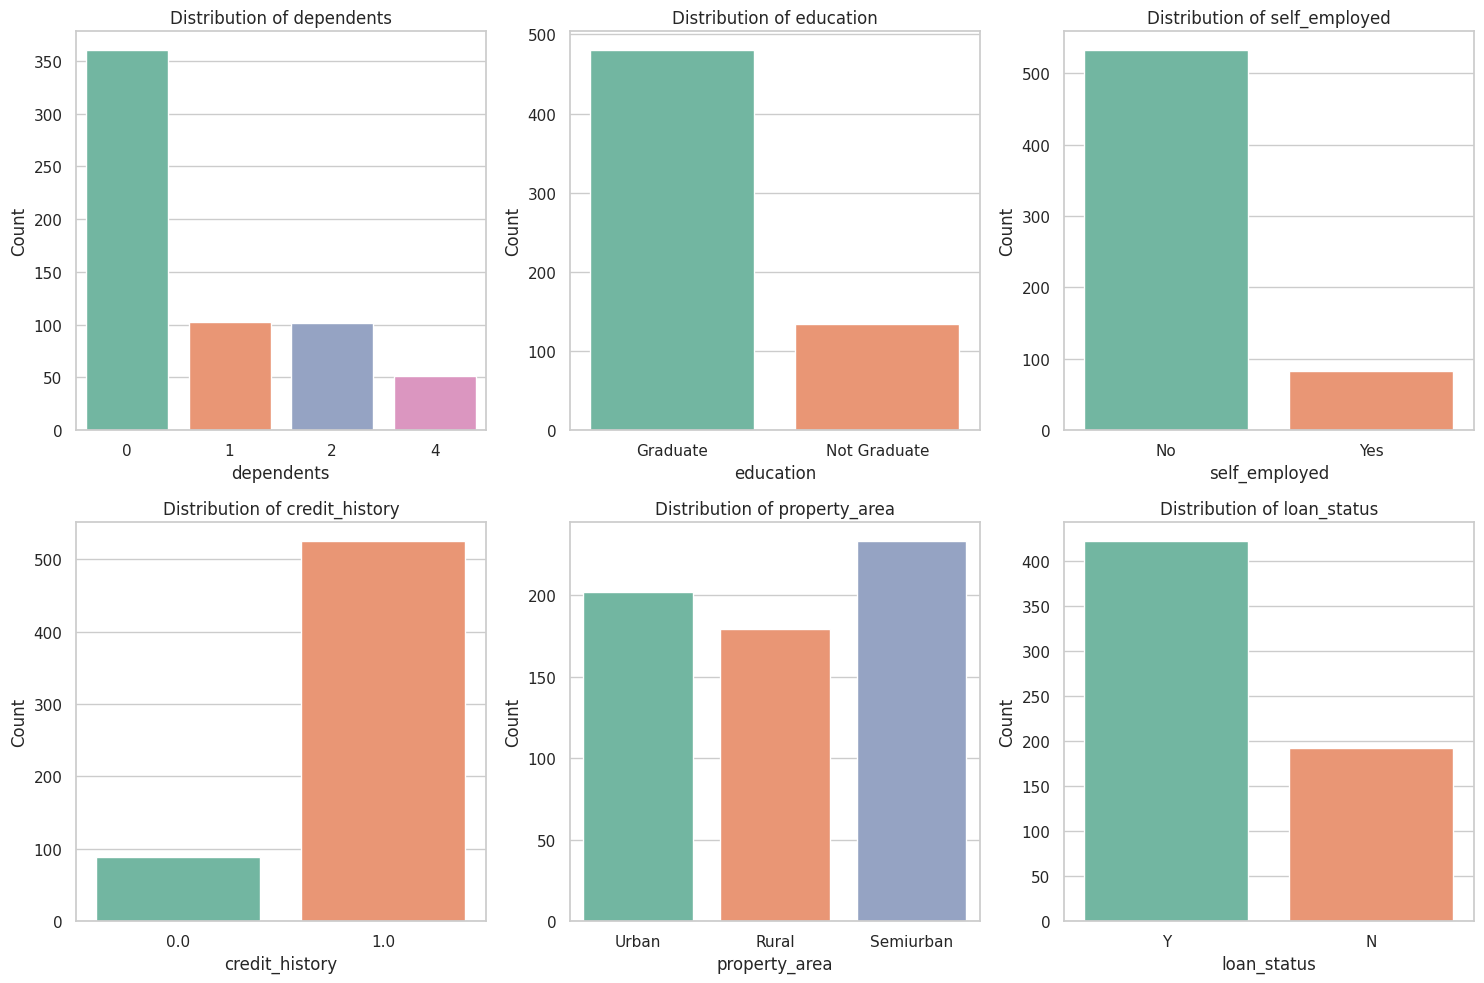

In [ ]:
# PART 1: UNIVARIATE ANALYSIS
# Analyzing one variable at a time (Distribution, Spread)

# Categorical Variables
cat_cols = ['dependents', 'education', 'self_employed', 'credit_history', 'property_area', 'loan_status']

plt.figure(figsize=(15, 10))
plot_idx = 1
for col in cat_cols:
    if col in df.columns:
        plt.subplot(2, 3, plot_idx)
        sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plot_idx += 1
plt.tight_layout()
plt.show()

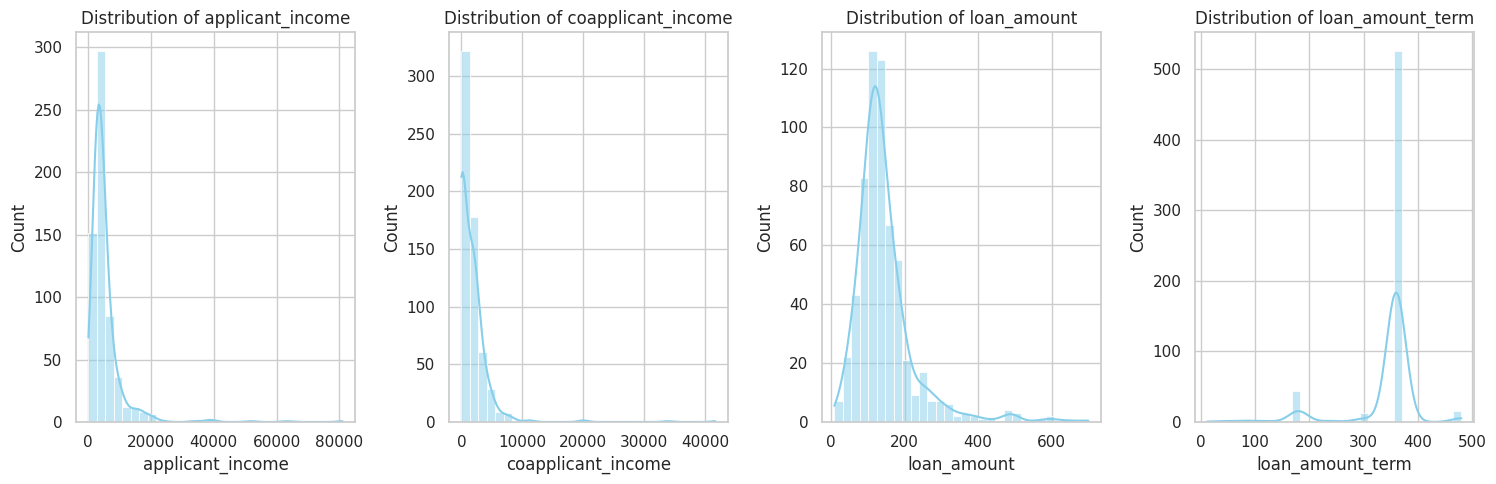

In [ ]:
# Numerical Variables (Histograms to check "Measures of Variance")
num_cols = ['applicant_income', 'coapplicant_income', 'loan_amount', 'loan_amount_term']

plt.figure(figsize=(15, 5))
plot_idx = 1
for col in num_cols:
    if col in df.columns:
        plt.subplot(1, 4, plot_idx)
        sns.histplot(df[col], kde=True, bins=30, color='skyblue')
        plt.title(f'Distribution of {col}')
        plot_idx += 1
plt.tight_layout()
plt.show()

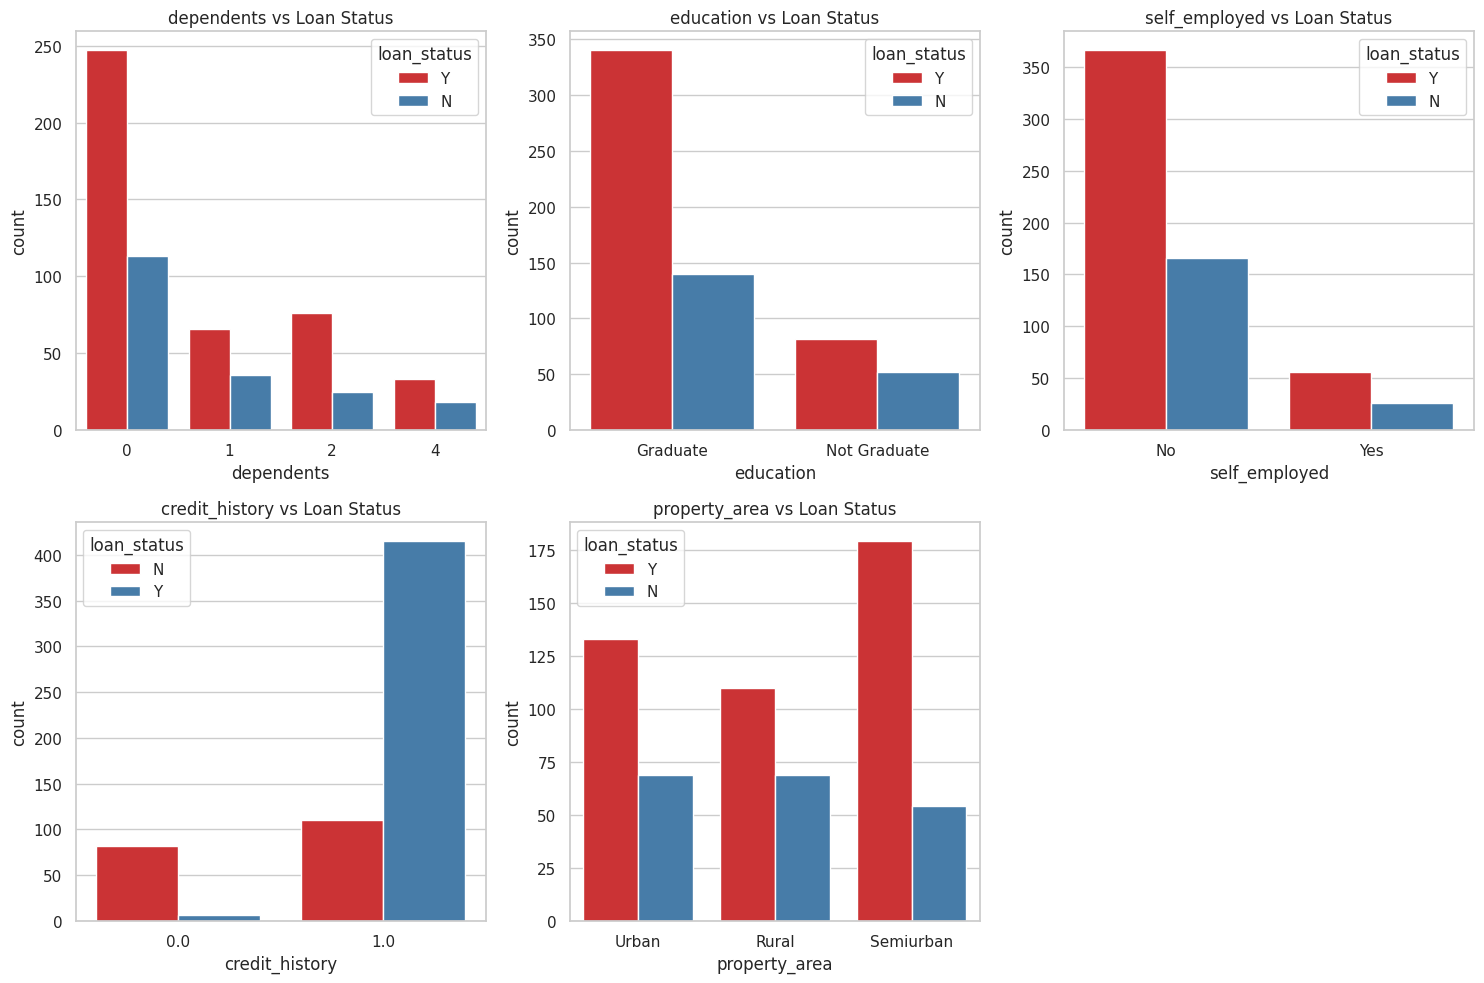

In [ ]:
# PART 2: BIVARIATE ANALYSIS
# Assessing interactions between variables and the target (Loan_Status)

# Categorical vs Loan_Status (Approval Rates)
plt.figure(figsize=(15, 10))
plot_idx = 1
for col in cat_cols:
    if col != 'loan_status' and col in df.columns:
        plt.subplot(2, 3, plot_idx)
        sns.countplot(data=df, x=col, hue='loan_status', palette='Set1')
        plt.title(f'{col} vs Loan Status')
        plot_idx += 1
plt.tight_layout()
plt.show()

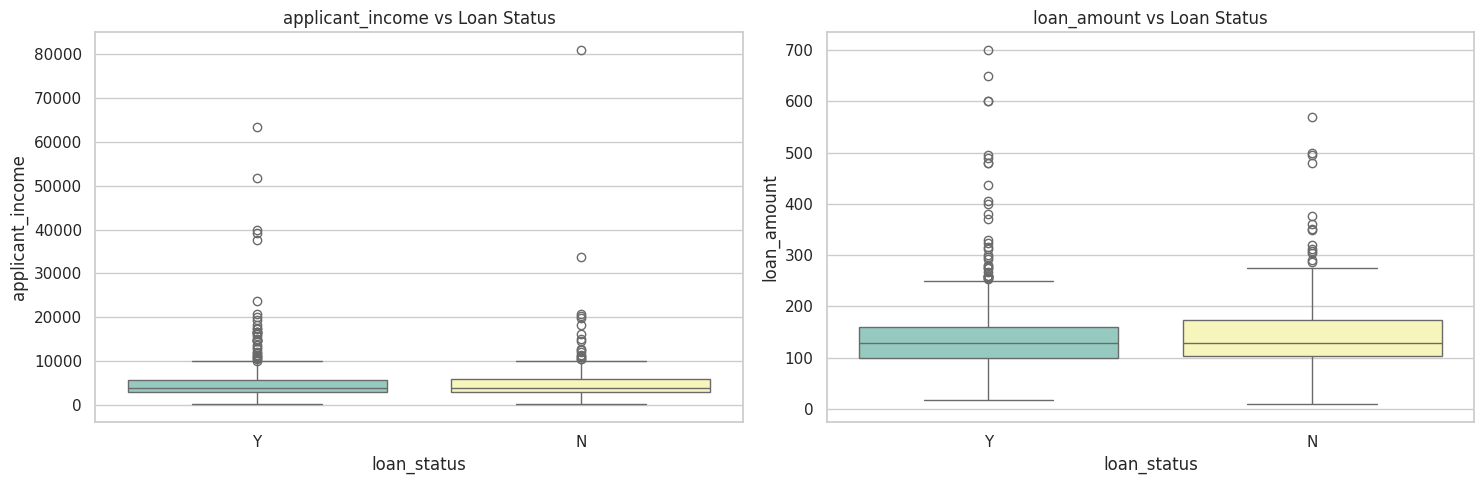

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical vs Loan_Status (Boxplots for outliers and spread)
plt.figure(figsize=(15, 5))
plot_idx = 1
for col in ['applicant_income', 'loan_amount']:
    if col in df.columns:
        plt.subplot(1, 2, plot_idx)
        sns.boxplot(data=df, x='loan_status', y=col, hue='loan_status', palette='Set3', legend=False)
        plt.title(f'{col} vs Loan Status')
        plot_idx += 1
plt.tight_layout()
plt.show()